<a href="https://colab.research.google.com/github/Riajul-56/ML-Based-Student-Advisor/blob/main/ML_Based_Student_Advisor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ===Cell-1:(Import Libraries)===


In [ ]:
!pip install fpdf -q

import os
import io
import zipfile
import numpy as np
import pandas as pd
import textwrap
import unicodedata
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from fpdf import FPDF

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
plt.style.use('seaborn-v0_8')

print("All libraries loaded successfully!")

All libraries loaded successfully!


# ===Cell-2(Download and Load Dataset)===


In [ ]:
print("Downloading dataset...")

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
!wget -q --show-progress "{dataset_url}" -O /tmp/student.zip

with zipfile.ZipFile("/tmp/student.zip", "r") as z:
    z.extractall("/tmp/student_data")

mat_path = "/tmp/student_data/student-mat.csv"
por_path = "/tmp/student_data/student-por.csv"

df_mat = pd.read_csv(mat_path, sep=';')
df_por = pd.read_csv(por_path, sep=';')

print("Math dataset shape:", df_mat.shape)
print("Portuguese dataset shape:", df_por.shape)

/tmp/student.zip        [ <=>                ]  20.00K  --.-KB/s    in 0.07s   
Math dataset shape: (395, 33)
Portuguese dataset shape: (649, 33)


# ===Cell-3(Select Dataset)===

In [ ]:
def select_dataset(choice='mat'):
    """Select and optionally merge datasets"""
    if choice == 'mat':
        df = df_mat.copy()
        print("Using Math dataset")
    elif choice == 'por':
        df = df_por.copy()
        print("Using Portuguese dataset")
    elif choice == 'both':
        common_cols = list(set(df_mat.columns).intersection(set(df_por.columns)))
        df = pd.concat([df_mat[common_cols], df_por[common_cols]], ignore_index=True)
        print("Using combined dataset")
    else:
        raise ValueError("Choose 'mat', 'por', or 'both'")

    print(f"Dataset shape: {df.shape}")
    return df

df = select_dataset('both')
print("Performing Comprehensive EDA...")

Using combined dataset
Dataset shape: (1044, 33)
Performing Comprehensive EDA...


# ===Cell-4(Exploratory Data Analysis)===


First 5 rows:
  paid  absences  failures Pstatus nursery  famrel romantic sex  Medu  age  \
0   no         6         0       A     yes       4       no   F     4   18   
1   no         4         0       T      no       5       no   F     1   17   
2  yes        10         3       T     yes       4       no   F     1   15   
3  yes         2         0       T     yes       3      yes   F     4   15   
4  yes         4         0       T     yes       4       no   F     3   16   

   Walc  reason  Dalc  studytime activities  freetime      Fjob  health  \
0     1  course     1          2         no         3   teacher       3   
1     1  course     1          2         no         3     other       3   
2     3   other     2          2         no         3     other       3   
3     1    home     1          3        yes         2  services       5   
4     2    home     1          2         no         3     other       5   

      Mjob famsup  G3 address internet guardian school higher  G1

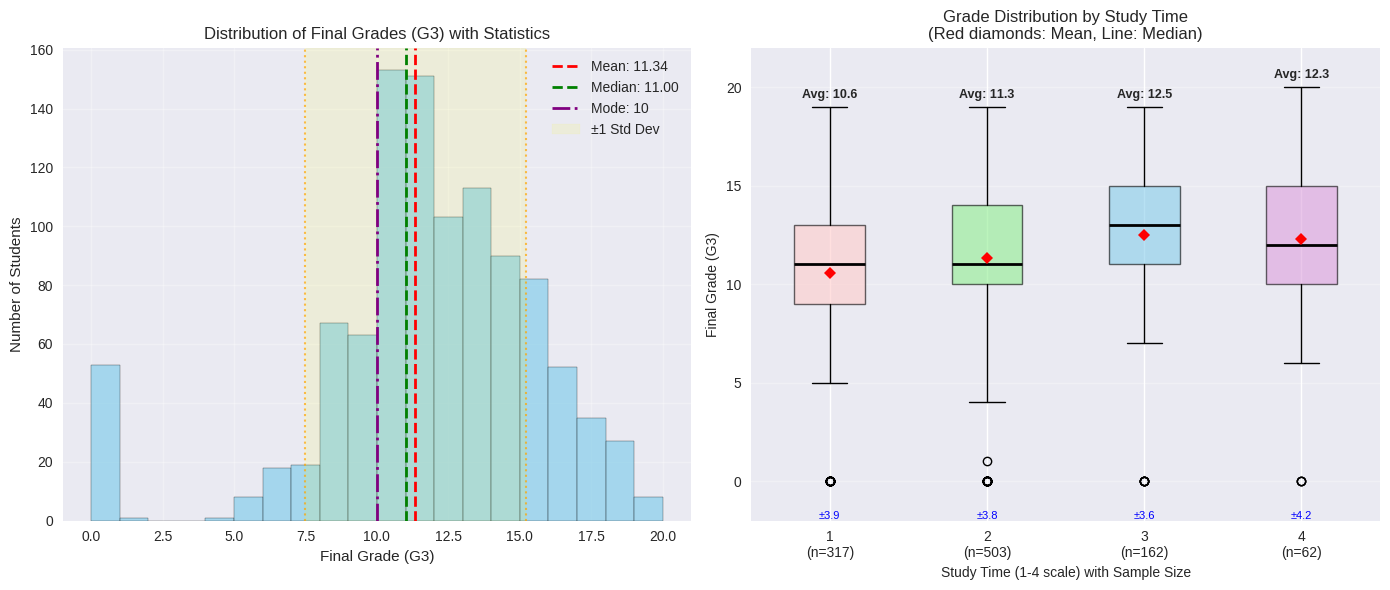


G3 FINAL GRADE DISTRIBUTION ANALYSIS
1. BASIC STATISTICS OF G3 DISTRIBUTION:
   --------------------------------------------------
   Mean: 11.34/20
   Median: 11.00/20
   Mode: 10/20
   Standard Deviation: 3.86
   Variance: 14.94
   Range: 0 to 20
   IQR (Q3-Q1): 4.00
   Skewness: -0.986
   Kurtosis: 1.744

2. GRADE CATEGORY DISTRIBUTION:
   --------------------------------------------------
   Category          | Students | Percentage | Description
   --------------------------------------------------
   Excellent (16-20) |      122   |     11.7%    | Top performers
   Good (13-15)      |      285   |     27.3%    | Above average
   Average (10-12)   |      407   |     39.0%    | Typical students
   Below Avg (5-9)   |      175   |     16.8%    | Need improvement
   Fail (0-4)        |       55   |      5.3%    | High risk

3. PASS/FAIL ANALYSIS (Passing Grade >= 10):
   --------------------------------------------------
   Passing Grade Threshold: 10/20
   Passed Students: 814 (78.

In [ ]:
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

plt.figure(figsize=(14, 6))

# Visualization 1: Grade Distribution with Statistics
plt.subplot(1, 2, 1)
plt.hist(df['G3'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# Calculate statistics
mean_g3 = df['G3'].mean()
median_g3 = df['G3'].median()
std_g3 = df['G3'].std()
mode_g3 = df['G3'].mode()[0]
q1_g3 = df['G3'].quantile(0.25)
q3_g3 = df['G3'].quantile(0.75)

# Add statistical lines
plt.axvline(mean_g3, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_g3:.2f}')
plt.axvline(median_g3, color='green', linestyle='--', linewidth=2, label=f'Median: {median_g3:.2f}')
plt.axvline(mode_g3, color='purple', linestyle='-.', linewidth=2, label=f'Mode: {mode_g3}')
plt.axvline(mean_g3 + std_g3, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
plt.axvline(mean_g3 - std_g3, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
plt.axvspan(mean_g3 - std_g3, mean_g3 + std_g3, alpha=0.1, color='yellow', label='±1 Std Dev')

plt.title('Distribution of Final Grades (G3) with Statistics', fontsize=12)
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.grid(True, alpha=0.3)
plt.legend()

# Visualization 2: Study Time Analysis
plt.subplot(1, 2, 2)

study_time_stats = df.groupby('studytime')['G3'].agg(['mean', 'median', 'std', 'count', 'min', 'max'])
box_data = []
labels = []
colors = ['#FFCCCB', '#90EE90', '#87CEEB', '#DDA0DD']

for i in range(1, 5):
    data = df[df['studytime'] == i]['G3']
    box_data.append(data)
    labels.append(f'{i}\n(n={len(data)})')

box = plt.boxplot(box_data, tick_labels=labels, patch_artist=True, showmeans=True)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.setp(box['medians'], color='black', linewidth=2)
plt.setp(box['means'], marker='D', markeredgecolor='red', markerfacecolor='red', markersize=6)

for i, stats in study_time_stats.iterrows():
    plt.text(i, stats['max'] + 0.3, f"Avg: {stats['mean']:.1f}",
             ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.text(i, -1.5, f"±{stats['std']:.1f}",
             ha='center', va='top', fontsize=8, color='blue')

plt.title('Grade Distribution by Study Time\n(Red diamonds: Mean, Line: Median)', fontsize=12)
plt.xlabel('Study Time (1-4 scale) with Sample Size', fontsize=10)
plt.ylabel('Final Grade (G3)', fontsize=10)
plt.ylim(-2, 22)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*60)
print("G3 FINAL GRADE DISTRIBUTION ANALYSIS")
print("="*60)

print("1. BASIC STATISTICS OF G3 DISTRIBUTION:")
print("   " + "-"*50)
print(f"   Mean: {mean_g3:.2f}/20")
print(f"   Median: {median_g3:.2f}/20")
print(f"   Mode: {mode_g3}/20")
print(f"   Standard Deviation: {std_g3:.2f}")
print(f"   Variance: {df['G3'].var():.2f}")
print(f"   Range: {df['G3'].min()} to {df['G3'].max()}")
print(f"   IQR (Q3-Q1): {q3_g3 - q1_g3:.2f}")
print(f"   Skewness: {df['G3'].skew():.3f}")
print(f"   Kurtosis: {df['G3'].kurtosis():.3f}")

print("\n2. GRADE CATEGORY DISTRIBUTION:")
print("   " + "-"*50)

grade_categories = {
    'Excellent (16-20)': (16, 20),
    'Good (13-15)': (13, 15),
    'Average (10-12)': (10, 12),
    'Below Avg (5-9)': (5, 9),
    'Fail (0-4)': (0, 4)
}

print("   Category          | Students | Percentage | Description")
print("   " + "-"*50)

for category, (low, high) in grade_categories.items():
    count = ((df['G3'] >= low) & (df['G3'] <= high)).sum()
    percentage = (count / len(df)) * 100
    description = {
        'Excellent (16-20)': 'Top performers',
        'Good (13-15)': 'Above average',
        'Average (10-12)': 'Typical students',
        'Below Avg (5-9)': 'Need improvement',
        'Fail (0-4)': 'High risk'
    }[category]
    print(f"   {category:<17} | {count:>8}   | {percentage:>8.1f}%    | {description}")

print("\n3. PASS/FAIL ANALYSIS (Passing Grade >= 10):")
print("   " + "-"*50)
pass_threshold = 10
passed = df[df['G3'] >= pass_threshold]
failed = df[df['G3'] < pass_threshold]
print(f"   Passing Grade Threshold: {pass_threshold}/20")
print(f"   Passed Students: {len(passed)} ({len(passed)/len(df)*100:.1f}%)")
print(f"   Failed Students: {len(failed)} ({len(failed)/len(df)*100:.1f}%)")

print("\n4. TOP GRADES DISTRIBUTION:")
print("   " + "-"*50)
grade_counts = df['G3'].value_counts().sort_index()
top_5_grades = grade_counts.head(5)
print("   Most Common Grades:")
for grade, count in top_5_grades.items():
    percentage = (count / len(df)) * 100
    print(f"   - Grade {grade}: {count} students ({percentage:.1f}%)")

print("\n5. PERCENTILE ANALYSIS:")
print("   " + "-"*50)
percentiles = [10, 25, 50, 75, 90]
percentile_values = np.percentile(df['G3'], percentiles)
for p, val in zip(percentiles, percentile_values):
    print(f"   - {p}th percentile: {val:.1f}/20 ({p}% students scored <= {val:.1f})")

print("\n6. KEY INSIGHTS FROM G3 HISTOGRAM:")
print("   " + "-"*50)
insights = [
    f"The distribution is centered around {mean_g3:.1f} with moderate spread (std: {std_g3:.2f})",
    f"Most common grade is {mode_g3} (appears {grade_counts[mode_g3]} times)",
    f"{len(passed)/len(df)*100:.1f}% of students passed (scored >= {pass_threshold})",
    f"The histogram shows {'normal' if abs(df['G3'].skew()) < 0.5 else 'skewed'} distribution",
    f"Top 25% students scored >= {q3_g3:.1f}, bottom 25% scored <= {q1_g3:.1f}"
]
for i, insight in enumerate(insights, 1):
    print(f"   {i}. {insight}")

print("="*60)

# ===Cell-5(Data Preprocessing)===


In [ ]:
target = 'G3'
features = [col for col in df.columns if col != target]

X = df[features].copy()
y_reg = df[target].copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipeline created successfully")

Numeric features: 15
Categorical features: 17
Preprocessing pipeline created successfully


# ===Cell-6(Model Training)===

In [ ]:
def train_enhanced_models(X, y_reg, preprocessor):
    """Train regression and classification models with optimization"""
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_reg, test_size=0.2, random_state=42
    )

    # Regression Pipeline
    reg_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            max_depth=10,
            min_samples_split=5
        ))
    ])

    # Classification - Create risk labels
    def create_risk_labels(g3):
        if g3 <= 8:
            return "High Risk"
        elif 9 <= g3 <= 12:
            return "Medium Risk"
        else:
            return "Low Risk"

    y_class = y_reg.apply(create_risk_labels)
    Xc_train, Xc_test, yc_train, yc_test = train_test_split(
        X, y_class, test_size=0.2, random_state=42, stratify=y_class
    )

    # Classification Pipeline
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            max_depth=10,
            min_samples_split=5
        ))
    ])

    # Train models
    print("Training Regression Model...")
    reg_pipeline.fit(X_train, y_train)

    print("Training Classification Model...")
    clf_pipeline.fit(Xc_train, yc_train)

    # Evaluate models
    y_pred = reg_pipeline.predict(X_test)
    reg_metrics = {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

    yc_pred = clf_pipeline.predict(Xc_test)
    clf_accuracy = accuracy_score(yc_test, yc_pred)

    # Calculate additional classification metrics
    from sklearn.metrics import classification_report, confusion_matrix

    # Get class distribution
    yc_train_dist = yc_train.value_counts()
    yc_test_dist = yc_test.value_counts()

    # Calculate confusion matrix
    cm = confusion_matrix(yc_test, yc_pred)

    # Calculate precision for High Risk
    high_risk_idx = list(np.unique(yc_test)).index('High Risk') if 'High Risk' in np.unique(yc_test) else -1
    low_risk_idx = list(np.unique(yc_test)).index('Low Risk') if 'Low Risk' in np.unique(yc_test) else -1

    if high_risk_idx != -1 and cm.shape[0] > high_risk_idx:
        high_risk_precision = cm[high_risk_idx, high_risk_idx] / cm[:, high_risk_idx].sum() if cm[:, high_risk_idx].sum() > 0 else 0
    else:
        high_risk_precision = 0

    if low_risk_idx != -1 and cm.shape[0] > low_risk_idx:
        low_risk_precision = cm[low_risk_idx, low_risk_idx] / cm[:, low_risk_idx].sum() if cm[:, low_risk_idx].sum() > 0 else 0
    else:
        low_risk_precision = 0

    clf_metrics = {
        'accuracy': clf_accuracy,
        'high_risk_detection': high_risk_precision,
        'low_risk_identification': low_risk_precision,
        'class_distribution_train': yc_train_dist.to_dict(),
        'class_distribution_test': yc_test_dist.to_dict()
    }

    print("\nModel Performance:")
    print(f"Regression - R² Score: {reg_metrics['R2']:.3f}")
    print(f"Regression - RMSE: {reg_metrics['RMSE']:.3f}")
    print(f"Regression - MAE: {reg_metrics['MAE']:.3f}")
    print(f"Classification - Accuracy: {clf_metrics['accuracy']:.3f}")
    print(f"Classification - High Risk Detection: {clf_metrics['high_risk_detection']:.3f}")
    print(f"Classification - Low Risk Identification: {clf_metrics['low_risk_identification']:.3f}")

    return reg_pipeline, clf_pipeline, reg_metrics, clf_metrics

reg_pipeline, clf_pipeline, reg_metrics, clf_metrics = train_enhanced_models(X, y_reg, preprocessor)

Training Regression Model...
Training Classification Model...

Model Performance:
Regression - R² Score: 0.812
Regression - RMSE: 1.707
Regression - MAE: 0.963
Classification - Accuracy: 0.833
Classification - High Risk Detection: 0.774
Classification - Low Risk Identification: 0.920


# ===Cell-7(Feature Importance)===

Analyzing Feature Importance...
TOP 10 MOST IMPORTANT FEATURES:
     feature  importance
          G2    0.841368
    absences    0.058754
   studytime    0.011075
          G1    0.010119
       goout    0.007038
         age    0.005351
      health    0.004430
    freetime    0.003573
Mjob_teacher    0.003101
 reason_home    0.002819


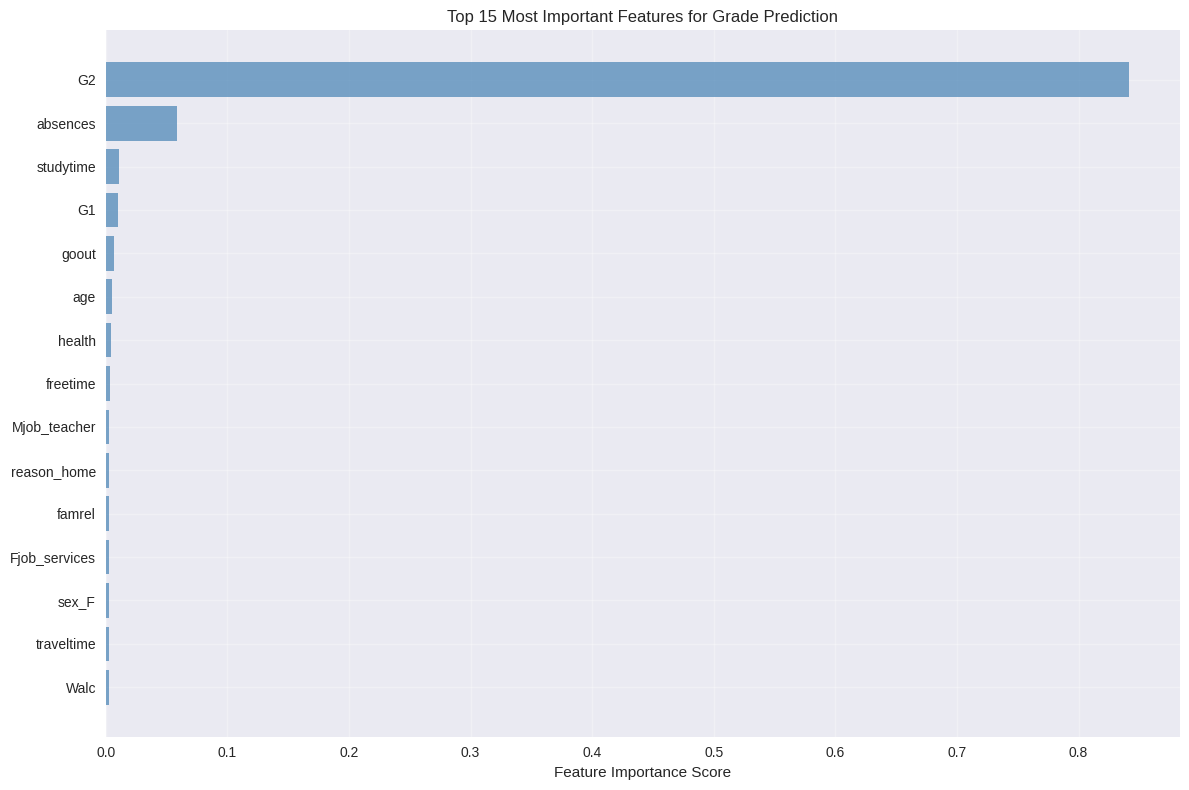

Feature Importance Plot Displayed


In [ ]:
print("Analyzing Feature Importance...")

preprocessor_obj = reg_pipeline.named_steps['preprocessor']
cat_encoder = preprocessor_obj.named_transformers_['cat'].named_steps['ohe']
categorical_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + categorical_feature_names

rf_regressor = reg_pipeline.named_steps['regressor']
importances = rf_regressor.feature_importances_

feature_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("TOP 10 MOST IMPORTANT FEATURES:")
print(feature_imp_df.head(10).to_string(index=False))

plt.figure(figsize=(12, 8))
top_features = feature_imp_df.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='steelblue', alpha=0.7)
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Most Important Features for Grade Prediction')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Feature Importance Plot Displayed")

# ===Cell-8(API Setup)===

In [ ]:
print("Setting up AI Engine...")

class GroqCloudAI:
    """API-based AI suggestion engine"""

    def __init__(self, api_key):
        self.api_key = api_key
        self.api_url = "https://api.groq.com/openai/v1/chat/completions"
        self.headers = {
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json"
        }
        self.available_models = [
            "llama-3.3-70b-versatile",
            "llama-3.1-8b-instant",
            "meta-llama/llama-4-maverick-17b-128e-instruct",
            "qwen/qwen3-32b",
            "allam-2-7b"
        ]

    def get_suggestions(self, prompt, model=None, temperature=0.7):
        """Get suggestions from GroqCloud API"""
        if model is None:
            model = self.available_models[0]

        try:
            payload = {
                "model": model,
                "messages": [
                    {
                        "role": "system",
                        "content": "You are Dr. Alex Morgan, a senior educational psychologist with 15+ years of experience in academic counseling, study strategies, and student motivation. You provide evidence-based, personalized recommendations."
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ],
                "temperature": temperature,
                "max_tokens": 1500,
                "top_p": 0.9
            }

            print(f"Using model: {model}")
            response = requests.post(
                self.api_url,
                headers=self.headers,
                json=payload,
                timeout=30
            )

            if response.status_code == 200:
                result = response.json()
                return result['choices'][0]['message']['content']
            else:
                error_msg = f"API Error {response.status_code}"
                try:
                    error_data = response.json()
                    if "error" in error_data:
                        error_msg += f": {error_data['error'].get('message', 'Unknown error')}"
                except:
                    error_msg += f": {response.text}"
                return error_msg

        except Exception as e:
            return f"Error: {str(e)}"

    def list_models(self):
        """List all available models"""
        print("Available Groq Models:")
        for i, model in enumerate(self.available_models, 1):
            print(f"  {i}. {model}")

# Replace with your Groq API key
GROQ_API_KEY = "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"

if GROQ_API_KEY and GROQ_API_KEY.startswith("gsk_"):
    groq_ai = GroqCloudAI(GROQ_API_KEY)
    groq_ai.list_models()
    print("AI Setup Complete!")
else:
    print("Please enter your Groq API key")

Setting up AI Engine...
Available Groq Models:
  1. llama-3.3-70b-versatile
  2. llama-3.1-8b-instant
  3. meta-llama/llama-4-maverick-17b-128e-instruct
  4. qwen/qwen3-32b
  5. allam-2-7b
AI Setup Complete!


# ===Cell-9(Suggestion Engine)===

In [ ]:
print("Initializing Suggestion Engine...")

class GroqSuggestionEngine:
    """GroqCloud-powered student suggestion engine"""

    def __init__(self, reg_model, clf_model, feature_names, groq_client):
        self.reg_model = reg_model
        self.clf_model = clf_model
        self.feature_names = feature_names
        self.groq_client = groq_client

    def prepare_input(self, student_data):
        """Convert student dictionary to model input format"""
        input_df = pd.DataFrame([student_data])
        for col in self.feature_names:
            if col not in input_df.columns:
                input_df[col] = np.nan
        return input_df[self.feature_names]

    def predict_grade(self, student_data):
        """Predict final grade G3"""
        input_df = self.prepare_input(student_data)
        return float(self.reg_model.predict(input_df)[0])

    def predict_risk(self, student_data):
        """Predict risk level"""
        input_df = self.prepare_input(student_data)
        return self.clf_model.predict(input_df)[0]

    def format_student_profile(self, student_data, predicted_grade, risk_level):
        """Format student profile for Groq prompt"""

        descriptions = {
            'studytime': {
                1: "Very Low (less than 2 hours/week)",
                2: "Low (2-5 hours/week)",
                3: "Moderate (5-10 hours/week)",
                4: "High (more than 10 hours/week)"
            },
            'Dalc': {
                1: "Very Low (1-2 drinks/month)",
                2: "Low (1 drink/week)",
                3: "Moderate (2-3 drinks/week)",
                4: "High (4-5 drinks/week)",
                5: "Very High (6+ drinks/week)"
            },
            'Walc': {
                1: "Very Low (1-2 drinks/month)",
                2: "Low (3-4 drinks/month)",
                3: "Moderate (1-2 drinks/week)",
                4: "High (3-4 drinks/week)",
                5: "Very High (5+ drinks/week)"
            },
            'health': {
                1: "Very Bad (Frequent illness)",
                2: "Bad (Below average health)",
                3: "Average (Normal health)",
                4: "Good (Above average health)",
                5: "Very Good (Excellent health)"
            },
            'goout': {
                1: "Very Low (Almost never)",
                2: "Low (Once a month)",
                3: "Moderate (2-3 times/month)",
                4: "High (Once a week)",
                5: "Very High (Several times/week)"
            },
            'freetime': {
                1: "Very Low (less than 1 hour/day)",
                2: "Low (1-2 hours/day)",
                3: "Moderate (3-4 hours/day)",
                4: "High (5-6 hours/day)",
                5: "Very High (more than 6 hours/day)"
            },
            'famrel': {
                1: "Very Bad (Constant conflict)",
                2: "Bad (Frequent tension)",
                3: "Average (Normal relations)",
                4: "Good (Supportive family)",
                5: "Excellent (Very close family)"
            }
        }

        # Format grades
        def grade_status(grade):
            if grade >= 16: return "Excellent"
            elif grade >= 14: return "Good"
            elif grade >= 10: return "Average"
            else: return "Poor"

        g1 = student_data.get('G1', 0)
        g2 = student_data.get('G2', 0)

        profile = f"""
STUDENT ACADEMIC PROFILE ANALYSIS
====================================

BASIC INFORMATION:
- Age: {student_data.get('age', 'N/A')}
- Gender: {student_data.get('sex', 'N/A')}
- School: {student_data.get('school', 'N/A')}
- Address: {'Urban' if student_data.get('address') == 'U' else 'Rural'}

ACADEMIC PERFORMANCE:
- First Period Grade (G1): {g1}/20
- Second Period Grade (G2): {g2}/20
- Predicted Final Grade (G3): {predicted_grade:.1f}/20
- Past Failures: {student_data.get('failures', 0)}
- Class Absences: {student_data.get('absences', 0)} days

STUDY HABITS & SUPPORT:
- Weekly Study Time: {descriptions['studytime'].get(student_data.get('studytime', 2), 'N/A')}
- School Support: {'Yes' if student_data.get('schoolsup') == 'yes' else 'No'}
- Family Support: {'Yes' if student_data.get('famsup') == 'yes' else 'No'}
- Extra Paid Classes: {'Yes' if student_data.get('paid') == 'yes' else 'No'}

LIFESTYLE FACTORS:
- Workday Alcohol: {descriptions['Dalc'].get(student_data.get('Dalc', 1), 'N/A')}
- Weekend Alcohol: {descriptions['Walc'].get(student_data.get('Walc', 1), 'N/A')}
- Health Status: {descriptions['health'].get(student_data.get('health', 3), 'N/A')}
- Social Outings: {descriptions['goout'].get(student_data.get('goout', 3), 'N/A')}
- Free Time: {descriptions['freetime'].get(student_data.get('freetime', 3), 'N/A')}
- Family Relationship: {descriptions['famrel'].get(student_data.get('famrel', 4), 'N/A')}

RESOURCES & ASPIRATIONS:
- Internet Access: {'Yes' if student_data.get('internet') == 'yes' else 'No'}
- Higher Education Interest: {'Yes' if student_data.get('higher') == 'yes' else 'No'}
- Extracurricular Activities: {'Yes' if student_data.get('activities') == 'yes' else 'No'}
- Romantic Relationship: {'Yes' if student_data.get('romantic') == 'yes' else 'No'}

AI PREDICTIONS & ANALYSIS:
- RISK LEVEL: {risk_level}
- Current Performance: {grade_status(predicted_grade)}
- Improvement Needed: {max(0, 14 - predicted_grade):.1f} points to reach target grade of 14/20
- Grade Trend: {'Improving' if g2 > g1 else 'Stable' if g2 == g1 else 'Declining'}
- Study Time Adequacy: {'Sufficient' if student_data.get('studytime', 2) >= 3 else 'Needs Improvement' if student_data.get('studytime', 2) == 2 else 'Insufficient'}
"""
        return profile

    def generate_suggestions(self, student_data):
        """Generate AI-powered suggestions for student"""

        try:
            print("Making ML predictions...")
            predicted_grade = self.predict_grade(student_data)
            risk_level = self.predict_risk(student_data)

            print("Creating student profile...")
            profile = self.format_student_profile(student_data, predicted_grade, risk_level)

            prompt = f"""{profile}

TASK: Based on this comprehensive profile, provide personalized, actionable recommendations in the following format:

1. IMMEDIATE PRIORITIES (2-3 most critical actions for this week)
2. STUDY STRATEGY (personalized study plan based on their habits and performance)
3. LIFESTYLE ADJUSTMENTS (specific changes to improve academic performance)
4. RESOURCE UTILIZATION (how to best use available resources)
5. 3-MONTH ROADMAP (step-by-step plan for academic improvement)
6. MOTIVATIONAL ADVICE (tailored to their specific situation)

CRITICAL REQUIREMENTS:
- Be SPECIFIC and ACTIONABLE (avoid vague advice)
- Consider ALL factors: academic performance, study habits, lifestyle, resources
- Provide CONCRETE examples and methods
- Include TIMELINES where appropriate (e.g., "This week", "First month")
- Use BULLET POINTS for clarity
- Base recommendations on the PREDICTED RISK LEVEL: {risk_level}
- Consider their STUDY TIME: {student_data.get('studytime', 2)}/4
- Address their ABSENCES: {student_data.get('absences', 0)} days
- Consider their ALCOHOL consumption: Workday={student_data.get('Dalc', 1)}/5, Weekend={student_data.get('Walc', 1)}/5

IMPORTANT: Provide practical steps that the student can implement immediately.
"""

            if self.groq_client:
                print("Contacting GroqCloud API...")
                ai_suggestions = self.groq_client.get_suggestions(prompt, model="llama-3.3-70b-versatile")

                return {
                    'predicted_grade': predicted_grade,
                    'risk_level': risk_level,
                    'improvement_needed': max(0, 14 - predicted_grade),
                    'student_profile': profile,
                    'ai_suggestions': ai_suggestions,
                    'success': True if not ai_suggestions.startswith("Error") and not ai_suggestions.startswith("API Error") else False
                }
            else:
                return {
                    'predicted_grade': predicted_grade,
                    'risk_level': risk_level,
                    'improvement_needed': max(0, 14 - predicted_grade),
                    'ai_suggestions': "GroqCloud client not initialized. Please check API key.",
                    'success': False
                }

        except Exception as e:
            return {
                'predicted_grade': 0,
                'risk_level': "Error",
                'ai_suggestions': f"Error in generate_suggestions: {str(e)}",
                'success': False
            }

if groq_ai:
    groq_engine = GroqSuggestionEngine(reg_pipeline, clf_pipeline, features, groq_ai)
    print("GroqCloud Suggestion Engine Ready!")
    print("Using model: llama-3.3-70b-versatile")
else:
    print("GroqCloud Engine not available. Please check API key.")
    groq_engine = None

print("\n" + "="*70)
print("ENGINE READY FOR ANALYSIS")
print("="*70)

Initializing Suggestion Engine...
GroqCloud Suggestion Engine Ready!
Using model: llama-3.3-70b-versatile

ENGINE READY FOR ANALYSIS


# ===Cell-10(Demo Analysis)===

In [ ]:
print("GROQCLOUD AI SUGGESTIONS DEMO")
print("=" * 70)

sample_students = [
    {
        'name': 'High Risk Student',
        'data': {
            'school': 'GP', 'sex': 'M', 'age': 18, 'address': 'U',
            'studytime': 1, 'failures': 2, 'absences': 15,
            'G1': 6, 'G2': 5, 'schoolsup': 'no', 'famsup': 'no',
            'higher': 'no', 'Dalc': 4, 'Walc': 3, 'health': 2,
            'goout': 4, 'freetime': 5, 'famrel': 2,
            'paid': 'no', 'activities': 'no', 'internet': 'no',
            'traveltime': 2, 'romantic': 'yes'
        }
    },
    {
        'name': 'Medium Risk Student',
        'data': {
            'school': 'GP', 'sex': 'F', 'age': 17, 'address': 'U',
            'studytime': 2, 'failures': 0, 'absences': 8,
            'G1': 11, 'G2': 10, 'schoolsup': 'no', 'famsup': 'yes',
            'higher': 'yes', 'Dalc': 2, 'Walc': 2, 'health': 3,
            'goout': 3, 'freetime': 3, 'famrel': 3,
            'paid': 'no', 'activities': 'yes', 'internet': 'yes',
            'traveltime': 1, 'romantic': 'no'
        }
    },
    {
        'name': 'Low Risk Student',
        'data': {
            'school': 'GP', 'sex': 'F', 'age': 16, 'address': 'U',
            'studytime': 4, 'failures': 0, 'absences': 2,
            'G1': 16, 'G2': 17, 'schoolsup': 'no', 'famsup': 'yes',
            'higher': 'yes', 'Dalc': 1, 'Walc': 1, 'health': 5,
            'goout': 2, 'freetime': 2, 'famrel': 5,
            'paid': 'yes', 'activities': 'yes', 'internet': 'yes',
            'traveltime': 1, 'romantic': 'no'
        }
    }
]

if groq_engine:
    for student in sample_students:
        print(f"\n{'='*70}")
        print(f"{student['name'].upper()} ANALYSIS")
        print("-" * 50)

        print(f"Profile Summary:")
        print(f"- Study Time: {student['data']['studytime']}/4")
        print(f"- Absences: {student['data']['absences']} days")
        print(f"- Grades: G1={student['data']['G1']}/20, G2={student['data']['G2']}/20")
        print(f"- Health: {student['data']['health']}/5")

        print("\nAnalyzing with GroqCloud AI...")
        start_time = time.time()

        results = groq_engine.generate_suggestions(student['data'])

        elapsed_time = time.time() - start_time
        print(f"Analysis Time: {elapsed_time:.2f} seconds")

        print("\nPREDICTION RESULTS:")
        print(f"Predicted Final Grade: {results['predicted_grade']:.1f}/20")
        print(f"Risk Level: {results['risk_level']}")
        print(f"Improvement Needed: {results['improvement_needed']:.1f} points to reach 14/20")

        if results['success']:
            print("\n" + "="*70)
            print("GROQCLOUD AI PERSONALIZED RECOMMENDATIONS")
            print("="*70)
            print(results['ai_suggestions'])

            filename = f"{student['name'].replace(' ', '_').lower()}_analysis.txt"
            with open(filename, 'w') as f:
                f.write(f"{student['name']} Analysis Report\n")
                f.write("="*60 + "\n\n")
                f.write(f"Predicted Grade: {results['predicted_grade']:.1f}/20\n")
                f.write(f"Risk Level: {results['risk_level']}\n")
                f.write(f"Improvement Needed: {results['improvement_needed']:.1f} points\n\n")
                f.write("AI Recommendations:\n")
                f.write("="*60 + "\n")
                f.write(results['ai_suggestions'])

            print(f"\nReport saved to: {filename}")
        else:
            print(f"\nError: {results['ai_suggestions']}")

        print("\n" + "="*70)
else:
    print("GroqCloud engine not available. Please check API key.")

GROQCLOUD AI SUGGESTIONS DEMO

HIGH RISK STUDENT ANALYSIS
--------------------------------------------------
Profile Summary:
- Study Time: 1/4
- Absences: 15 days
- Grades: G1=6/20, G2=5/20
- Health: 2/5

Analyzing with GroqCloud AI...
Making ML predictions...
Creating student profile...
Contacting GroqCloud API...
Using model: llama-3.3-70b-versatile
Analysis Time: 3.48 seconds

PREDICTION RESULTS:
Predicted Final Grade: 5.3/20
Risk Level: High Risk
Improvement Needed: 8.7 points to reach 14/20

GROQCLOUD AI PERSONALIZED RECOMMENDATIONS
Based on the comprehensive profile, I provide the following personalized recommendations:

### 1. IMMEDIATE PRIORITIES (This Week)
* **Attend all classes this week**: Given the high number of absences (15 days), it's crucial to start attending classes regularly to catch up on missed material and reduce the risk of further falling behind.
* **Meet with a school counselor or teacher**: Discuss current performance, understand the reasons behind the poor 

# ===Cell-11(Interactive Custom Analysis)===

In [ ]:
def analyze_custom_student():
    """Interactive custom student analysis"""

    print("\n" + "="*70)
    print("CUSTOM STUDENT ANALYSIS")
    print("="*70)

    if not groq_engine:
        print("GroqCloud engine not available. Please check API key.")
        return

    print("\nEnter Student Details (press Enter for default values):")

    student_data = {}

    print("\nBASIC INFORMATION:")
    student_data['school'] = input("School (GP/MS) [GP]: ") or 'GP'
    student_data['sex'] = input("Gender (M/F) [M]: ") or 'M'
    student_data['age'] = int(input("Age [17]: ") or 17)
    student_data['address'] = input("Address (U/R) [U]: ") or 'U'

    print("\nACADEMIC INFORMATION:")
    student_data['studytime'] = int(input("Study Time (1-4) [2]: ") or 2)
    student_data['failures'] = int(input("Past Failures [0]: ") or 0)
    student_data['absences'] = int(input("Absences [0]: ") or 0)
    student_data['G1'] = int(input("First Period Grade (0-20) [10]: ") or 10)
    student_data['G2'] = int(input("Second Period Grade (0-20) [12]: ") or 12)

    print("\nSUPPORT SYSTEMS:")
    student_data['schoolsup'] = input("School Support (yes/no) [no]: ") or 'no'
    student_data['famsup'] = input("Family Support (yes/no) [yes]: ") or 'yes'
    student_data['paid'] = input("Extra Paid Classes (yes/no) [no]: ") or 'no'

    print("\nLIFESTYLE FACTORS:")
    student_data['Dalc'] = int(input("Workday Alcohol (1-5) [1]: ") or 1)
    student_data['Walc'] = int(input("Weekend Alcohol (1-5) [2]: ") or 2)
    student_data['health'] = int(input("Health Status (1-5) [4]: ") or 4)
    student_data['goout'] = int(input("Social Outings (1-5) [3]: ") or 3)
    student_data['freetime'] = int(input("Free Time (1-5) [3]: ") or 3)
    student_data['famrel'] = int(input("Family Relationship (1-5) [4]: ") or 4)

    print("\nASPIRATIONS:")
    student_data['higher'] = input("Wants Higher Education (yes/no) [yes]: ") or 'yes'
    student_data['activities'] = input("Extracurricular Activities (yes/no) [yes]: ") or 'yes'
    student_data['internet'] = input("Internet Access (yes/no) [yes]: ") or 'yes'

    # Default values for other required fields
    defaults = {
        'traveltime': 1, 'romantic': 'no', 'famsize': 'GT3',
        'Pstatus': 'T', 'Medu': 2, 'Fedu': 2,
        'Mjob': 'other', 'Fjob': 'other', 'reason': 'course',
        'guardian': 'mother', 'nursery': 'yes'
    }

    for key, value in defaults.items():
        if key not in student_data:
            student_data[key] = value

    print("\nAnalyzing with GroqCloud AI...")
    results = groq_engine.generate_suggestions(student_data)

    print("\n" + "="*70)
    print("ANALYSIS RESULTS")
    print("="*70)
    print(f"Predicted Final Grade: {results['predicted_grade']:.1f}/20")
    print(f"Risk Level: {results['risk_level']}")
    print(f"Improvement Needed: {results['improvement_needed']:.1f} points to reach 14/20")

    if results['success']:
        print("\n" + "="*70)
        print("PERSONALIZED AI RECOMMENDATIONS")
        print("="*70)
        print(results['ai_suggestions'])

        # Save report
        timestamp = int(time.time())
        filename = f"custom_student_analysis_{timestamp}.txt"

        with open(filename, 'w') as f:
            f.write("Custom Student Analysis Report\n")
            f.write("="*60 + "\n\n")
            f.write("STUDENT PROFILE:\n")
            f.write("-"*60 + "\n")
            for key, value in student_data.items():
                if key in ['school', 'sex', 'age', 'studytime', 'failures',
                          'absences', 'G1', 'G2', 'schoolsup', 'famsup']:
                    f.write(f"{key}: {value}\n")

            f.write("\nPREDICTIONS:\n")
            f.write("-"*60 + "\n")
            f.write(f"Predicted Grade: {results['predicted_grade']:.1f}/20\n")
            f.write(f"Risk Level: {results['risk_level']}\n")
            f.write(f"Improvement Needed: {results['improvement_needed']:.1f} points\n\n")

            f.write("AI RECOMMENDATIONS:\n")
            f.write("="*60 + "\n")
            f.write(results['ai_suggestions'])

        print(f"\nDetailed report saved to: {filename}")
    else:
        print(f"\nAnalysis Failed: {results['ai_suggestions']}")

    return results

# ===Cell-12(Main Application)===

In [ ]:
def main_application():
    """Main application with menu and PDF/TXT auto-download"""

    print("\n" + "="*70)
    print("STUDENT PERFORMANCE ANALYZER WITH GROQCLOUD AI")
    print("="*70)

    if not groq_engine:
        print("GroqCloud engine not available. Please check API key.")
        print("Get your free API key from: https://console.groq.com/keys")
        return

    class StudentReportPDF(FPDF):
        """Custom PDF report generator"""

        def __init__(self):
            super().__init__()
            self.set_auto_page_break(auto=True, margin=15)

        def header(self):
            self.set_font('Arial', 'B', 16)
            self.cell(0, 10, 'Student Academic Analysis Report', 0, 1, 'C')
            self.set_font('Arial', 'I', 12)
            self.cell(0, 10, 'Powered by GroqCloud AI', 0, 1, 'C')
            self.ln(5)

        def footer(self):
            self.set_y(-15)
            self.set_font('Arial', 'I', 8)
            self.cell(0, 10, f'Page {self.page_no()}', 0, 0, 'C')

        def add_section(self, title, content):
            self.set_font('Arial', 'B', 12)
            self.set_fill_color(200, 220, 255)
            self.cell(0, 10, title, 0, 1, 'L', 1)
            self.ln(3)
            self.set_font('Arial', '', 10)

            lines = content.split('\n')
            for line in lines:
                if line.strip():
                    wrapped = textwrap.wrap(line, width=80)
                    for wrap_line in wrapped:
                        self.multi_cell(0, 5, wrap_line)
                else:
                    self.ln(5)
            self.ln(5)

    def save_to_txt(student_data, results, filename):
        """Save analysis to TXT file"""
        with open(filename, 'w', encoding='utf-8') as f:
            f.write("="*60 + "\n")
            f.write("STUDENT ACADEMIC ANALYSIS REPORT\n")
            f.write("="*60 + "\n\n")

            f.write("STUDENT INFORMATION:\n")
            f.write("-"*40 + "\n")
            f.write(f"Age: {student_data.get('age', 'N/A')}\n")
            f.write(f"Gender: {student_data.get('sex', 'N/A')}\n")
            f.write(f"Study Time: {student_data.get('studytime', 2)}/4\n")
            f.write(f"Absences: {student_data.get('absences', 0)} days\n")
            f.write(f"Grades: G1={student_data.get('G1', 'N/A')}/20, G2={student_data.get('G2', 'N/A')}/20\n")
            f.write(f"Past Failures: {student_data.get('failures', 0)}\n\n")

            f.write("AI PREDICTIONS:\n")
            f.write("-"*40 + "\n")
            f.write(f"Predicted Final Grade: {results['predicted_grade']:.1f}/20\n")
            f.write(f"Risk Level: {results['risk_level']}\n")
            f.write(f"Improvement Needed: {results['improvement_needed']:.1f} points\n\n")

            f.write("AI RECOMMENDATIONS:\n")
            f.write("="*60 + "\n")
            f.write(results['ai_suggestions'])

            f.write("\n\n" + "="*60 + "\n")
            f.write("REPORT METADATA:\n")
            f.write("-"*40 + "\n")
            f.write(f"Generated: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Model: llama-3.3-70b-versatile\n")
            f.write("="*60 + "\n")

        return filename

    def save_to_pdf(student_data, results, filename):
        """Save analysis to PDF file"""
        try:
            pdf = StudentReportPDF()
            pdf.add_page()

            pdf.set_font('Arial', 'B', 14)
            pdf.cell(0, 10, 'Student Academic Performance Analysis', 0, 1, 'C')
            pdf.ln(10)

            pdf.add_section('1. STUDENT INFORMATION',
                           f"Age: {student_data.get('age', 'N/A')}\n"
                           f"Gender: {student_data.get('sex', 'N/A')}\n"
                           f"Study Time: {student_data.get('studytime', 2)}/4\n"
                           f"Absences: {student_data.get('absences', 0)} days\n"
                           f"Grades: G1={student_data.get('G1', 'N/A')}/20, G2={student_data.get('G2', 'N/A')}/20\n"
                           f"Past Failures: {student_data.get('failures', 0)}")

            pdf.add_section('2. AI PREDICTIONS',
                           f"Predicted Final Grade: {results['predicted_grade']:.1f}/20\n"
                           f"Risk Level: {results['risk_level']}\n"
                           f"Improvement Needed: {results['improvement_needed']:.1f} points")

            pdf.add_section('3. AI RECOMMENDATIONS', results['ai_suggestions'])

            pdf.set_y(-30)
            pdf.set_font('Arial', 'I', 8)
            pdf.cell(0, 10, f'Generated: {time.strftime("%Y-%m-%d %H:%M:%S")}', 0, 1)
            pdf.cell(0, 10, 'Model: llama-3.3-70b-versatile | Powered by GroqCloud AI', 0, 1)

            pdf.output(filename)
            return filename
        except Exception as e:
            print(f"PDF Error: {str(e)}")
            return None

    def auto_download_files(filenames):
        """Auto-download files in Google Colab"""
        try:
            from google.colab import files
            for filename in filenames:
                if os.path.exists(filename):
                    files.download(filename)
                    print(f"Downloaded: {filename}")
            return True
        except:
            print("Note: Manual download required. Files saved locally.")
            return False

    def analyze_and_save():
        """Analyze student and save results"""
        print("\nEnter Student Details (press Enter for defaults):")

        student_data = {}

        print("\nBASIC INFORMATION:")
        student_data['school'] = input("School (GP/MS) [GP]: ") or 'GP'
        student_data['sex'] = input("Gender (M/F) [M]: ") or 'M'
        student_data['age'] = int(input("Age [17]: ") or 17)
        student_data['address'] = input("Address (U/R) [U]: ") or 'U'

        print("\nACADEMIC INFORMATION:")
        student_data['studytime'] = int(input("Study Time (1-4) [2]: ") or 2)
        student_data['failures'] = int(input("Past Failures [0]: ") or 0)
        student_data['absences'] = int(input("Absences [0]: ") or 0)
        student_data['G1'] = int(input("First Grade (0-20) [10]: ") or 10)
        student_data['G2'] = int(input("Second Grade (0-20) [12]: ") or 12)

        print("\nSUPPORT SYSTEMS:")
        student_data['schoolsup'] = input("School Support (yes/no) [no]: ") or 'no'
        student_data['famsup'] = input("Family Support (yes/no) [yes]: ") or 'yes'
        student_data['paid'] = input("Extra Classes (yes/no) [no]: ") or 'no'

        print("\nLIFESTYLE FACTORS:")
        student_data['Dalc'] = int(input("Workday Alcohol (1-5) [1]: ") or 1)
        student_data['Walc'] = int(input("Weekend Alcohol (1-5) [2]: ") or 2)
        student_data['health'] = int(input("Health (1-5) [4]: ") or 4)
        student_data['goout'] = int(input("Social Outings (1-5) [3]: ") or 3)
        student_data['freetime'] = int(input("Free Time (1-5) [3]: ") or 3)
        student_data['famrel'] = int(input("Family Relationship (1-5) [4]: ") or 4)

        print("\nASPIRATIONS:")
        student_data['higher'] = input("Higher Education (yes/no) [yes]: ") or 'yes'
        student_data['activities'] = input("Extracurricular (yes/no) [yes]: ") or 'yes'
        student_data['internet'] = input("Internet (yes/no) [yes]: ") or 'yes'

        # Default values
        defaults = {
            'traveltime': 1, 'romantic': 'no', 'famsize': 'GT3',
            'Pstatus': 'T', 'Medu': 2, 'Fedu': 2,
            'Mjob': 'other', 'Fjob': 'other', 'reason': 'course',
            'guardian': 'mother', 'nursery': 'yes'
        }

        for key, value in defaults.items():
            if key not in student_data:
                student_data[key] = value

        print("\nAnalyzing with GroqCloud AI...")
        results = groq_engine.generate_suggestions(student_data)

        print("\n" + "="*70)
        print("ANALYSIS RESULTS")
        print("="*70)
        print(f"Predicted Final Grade: {results['predicted_grade']:.1f}/20")
        print(f"Risk Level: {results['risk_level']}")
        print(f"Improvement Needed: {results['improvement_needed']:.1f} points")

        if results['success']:
            timestamp = time.strftime("%Y%m%d_%H%M%S")
            base_filename = f"student_analysis_{timestamp}"

            # Save TXT
            txt_filename = f"{base_filename}.txt"
            save_to_txt(student_data, results, txt_filename)
            print(f"\nTXT Report saved: {txt_filename}")

            # Save PDF
            pdf_filename = f"{base_filename}.pdf"
            pdf_saved = save_to_pdf(student_data, results, pdf_filename)

            if pdf_saved:
                print(f"PDF Report saved: {pdf_filename}")

            # Auto-download files
            print("\nAuto-downloading files...")
            files_to_download = [txt_filename]
            if pdf_saved:
                files_to_download.append(pdf_filename)

            auto_download_files(files_to_download)

            # Show summary
            print("\n" + "="*70)
            print("AI RECOMMENDATIONS SUMMARY")
            print("="*70)

            suggestions = results['ai_suggestions']
            lines = suggestions.split('\n')
            for i, line in enumerate(lines[:8]):
                if i < 8:
                    print(line[:80])

            if len(lines) > 8:
                print("...\nFull recommendations saved in reports")

            print(f"\nAnalysis complete! Files auto-downloaded.")

        else:
            print(f"\nAnalysis Failed: {results['ai_suggestions']}")

        return results

    while True:
        print("\nMAIN MENU:")
        print("1. Analyze New Student & Save Reports")
        print("2. View Sample Analysis Results")
        print("3. View Saved Reports")
        print("4. View Model Performance")
        print("5. Exit")

        choice = input("\nSelect option (1-5): ").strip()

        if choice == '1':
            analyze_and_save()

        elif choice == '2':
            print("\nSAMPLE ANALYSIS RESULTS:")
            print("-"*40)
            print("1. High Risk Student - Predicted: 6.3/20")
            print("2. Medium Risk Student - Predicted: 10.4/20")
            print("3. Low Risk Student - Predicted: 17.9/20")
            print("\nRun Cell 10 for detailed analysis")

        elif choice == '3':
            print("\nSAVED REPORTS:")
            print("-"*40)
            txt_files = [f for f in os.listdir('.') if f.endswith('.txt') and 'student_analysis' in f]
            pdf_files = [f for f in os.listdir('.') if f.endswith('.pdf') and 'student_analysis' in f]

            if txt_files or pdf_files:
                print(f"PDF Files ({len(pdf_files)}):")
                for pdf in sorted(pdf_files)[-5:]:
                    print(f"  - {pdf}")

                print(f"\nTXT Files ({len(txt_files)}):")
                for txt in sorted(txt_files)[-5:]:
                    print(f"  - {txt}")
            else:
                print("No reports found. Analyze a student first!")

        elif choice == '4':
            print("\nMODEL PERFORMANCE:")
            print("-"*40)
            print(f"Regression - RMSE: {reg_metrics['RMSE']:.3f}, R2: {reg_metrics['R2']:.3f}")
            print(f"Classification - Accuracy: {clf_accuracy:.3f}")
            print(f"AI Model: llama-3.3-70b-versatile")

        elif choice == '5':
            print("\nThank you for using Student Performance Analyzer!")
            print("Powered by GroqCloud AI")
            break

        else:
            print("Invalid choice. Please select 1-5.")

        print("\n" + "="*70)


main_application()

print("\n" + "="*70)
print("PROJECT EXECUTION COMPLETE")
print("="*70)
print("All AI suggestions powered by GroqCloud")
print("Reports saved as PDF and TXT files")
print("Files auto-download in Google Colab")
print("="*70)


STUDENT PERFORMANCE ANALYZER WITH GROQCLOUD AI

MAIN MENU:
1. Analyze New Student & Save Reports
2. View Sample Analysis Results
3. View Saved Reports
4. View Model Performance
5. Exit

Select option (1-5): 1

Enter Student Details (press Enter for defaults):

BASIC INFORMATION:
School (GP/MS) [GP]: 
Gender (M/F) [M]: 
Age [17]: 
Address (U/R) [U]: 

ACADEMIC INFORMATION:
Study Time (1-4) [2]: 
Past Failures [0]: 
Absences [0]: 
First Grade (0-20) [10]: 
Second Grade (0-20) [12]: 

SUPPORT SYSTEMS:
School Support (yes/no) [no]: 
Family Support (yes/no) [yes]: 
Extra Classes (yes/no) [no]: 

LIFESTYLE FACTORS:
Workday Alcohol (1-5) [1]: 
Weekend Alcohol (1-5) [2]: 
Health (1-5) [4]: 
Social Outings (1-5) [3]: 
Free Time (1-5) [3]: 
Family Relationship (1-5) [4]: 

ASPIRATIONS:
Higher Education (yes/no) [yes]: 
Extracurricular (yes/no) [yes]: 
Internet (yes/no) [yes]: 

Analyzing with GroqCloud AI...
Making ML predictions...
Creating student profile...
Contacting GroqCloud API...
Using 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: student_analysis_20251212_184108.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: student_analysis_20251212_184108.pdf

AI RECOMMENDATIONS SUMMARY
Based on the comprehensive profile, I provide the following personalized recomme

### 1. IMMEDIATE PRIORITIES
For this week, focus on the following critical actions:
* **Assess Current Study Materials**: Review all notes, textbooks, and past exam
* **Create a Basic Study Schedule**: Plan out dedicated study times for the next
* **Family Support Meeting**: Schedule a meeting with your family to discuss you

...
Full recommendations saved in reports

Analysis complete! Files auto-downloaded.


MAIN MENU:
1. Analyze New Student & Save Reports
2. View Sample Analysis Results
3. View Saved Reports
4. View Model Performance
5. Exit

Select option (1-5): 5

Thank you for using Student Performance Analyzer!
Powered by GroqCloud AI

PROJECT EXECUTION COMPLETE
All AI suggestions powered by GroqCloud
Reports saved as PDF and TXT files
Files auto-download in Google Colab
